In [11]:
!pip install ucimlrepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,StratifiedKFold, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from ucimlrepo import fetch_ucirepo
import numpy as np
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import uniform
from scipy.spatial.transform import Rotation as R
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay)
from scipy.stats import uniform

In [12]:
wdbc = fetch_ucirepo(id=17)
X = wdbc.data.features
y = wdbc.data.targets
features= ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columns=[f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]
X.columns= columns
cancer_df = pd.concat([y, X], axis=1)
cancer_df = cancer_df.rename(columns={'Diagnosis': 'diagnosis'})
cancer_df['diagnosis_binary'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
y = cancer_df['diagnosis_binary']

(569, 32)
  diagnosis  mean_radius  mean_texture  mean_perimeter  mean_area  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   mean_smoothness  mean_compactness  mean_concavity  mean_concave_points  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   mean_symmetry  ...  worst_texture  worst_perimeter  worst_area  \
0         0.2419  ...          17.33       

In [30]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=0, stratify=y)

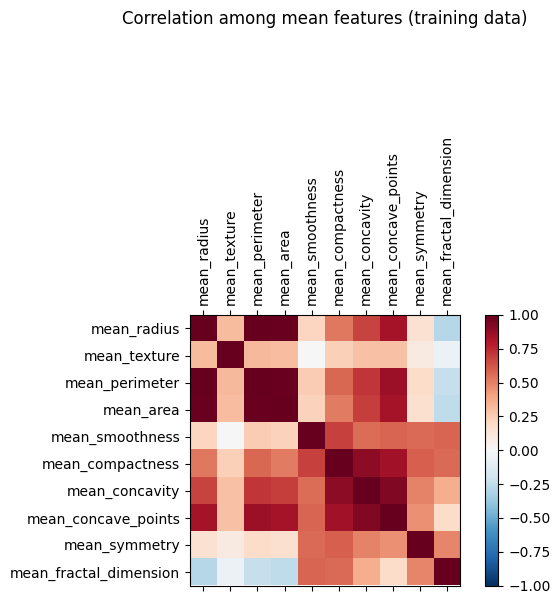

In [35]:
#Use mean columns only for visualization
mean_cols = [c for c in X_train.columns if c.startswith('mean_')]
corr = X_train[mean_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.matshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im)
ax.set_xticks(range(len(mean_cols)))
ax.set_yticks(range(len(mean_cols)))
ax.set_xticklabels(mean_cols, rotation=90)
ax.set_yticklabels(mean_cols)
ax.set_title('Correlation among mean features', pad=80)
plt.tight_layout()
plt.show()

In [31]:
std_pca = make_pipeline(StandardScaler(), PCA(n_components=10, random_state=0))
std_pca.fit(X_train)
pca = std_pca.named_steps['pca']
print(f'pca.explained_variance_ratio_={pca.explained_variance_ratio_}')
pca_X = std_pca.transform(X_train)

pca.explained_variance_ratio_=[0.44545454 0.1854487  0.09908318 0.06515676 0.05374362 0.03845634
 0.02331206 0.01590846 0.01413346 0.01166102]


we can see that PC1 explains 44.54% of the variance, followed by 18.54% and 9.9% of PC2 and PC3.Thus PC1 + PC2 can explain 63.1% of the total variance.
Also, the first ten direction can explain about 95% of the total variance.

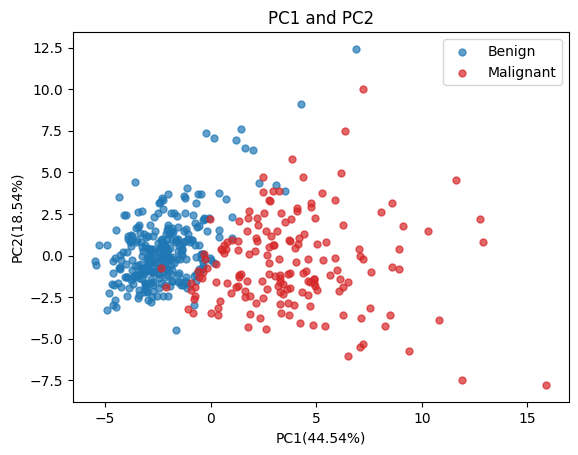

In [32]:
colors = {0: "tab:blue", 1: "tab:red"}

plt.xlabel('PC1(44.54%)')
plt.ylabel('PC2(18.54%)')
plt.title('PC1 and PC2')
mask_benign = (y_train == 0)
x_benign = pca_X[mask_benign, 0]
y_benign = pca_X[mask_benign, 1]
plt.scatter(x_benign, y_benign, c=colors[0], label='Benign', s=25, alpha=0.7)
plt.legend()

mask_malignant = (y_train == 1)
x_malignant = pca_X[mask_malignant, 0]
y_malignant = pca_X[mask_malignant, 1]
plt.scatter(x_malignant, y_malignant, c=colors[1], label='Malignant', s=25, alpha=0.7)
plt.legend()

From this plot we can see that the Benign cases tends to concentrate on x-axis where PC1 is negative while malignant cases concentrate on positive PC1 side.

As the diagnosis cases do not show a clear classification pattern on y-axis, we can conclude that PC1 is closely associated with the diagnosis cases.

However, the points still overlaps especially in the area where x-axis == 0, so there still exist variance that can not be explained by PC1 and PC2.


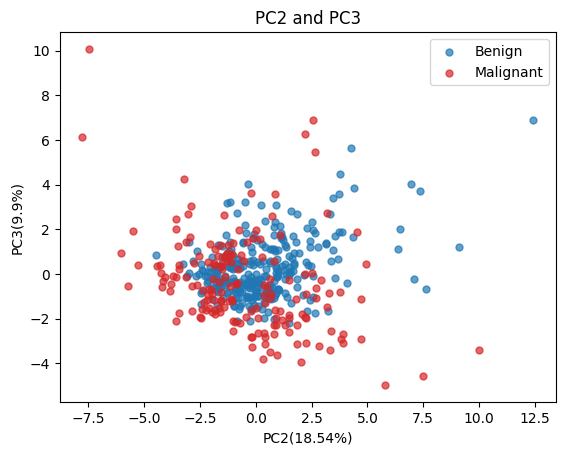

In [26]:
plt.xlabel('PC2(18.54%)')
plt.ylabel('PC3(9.9%)')
plt.title('PC2 and PC3')
mask_benign = (y_train == 0)
x_benign = pca_X[mask_benign, 1]
y_benign = pca_X[mask_benign, 2]
plt.scatter(x_benign, y_benign, c=colors[0], label='Benign', s=25, alpha=0.7)
plt.legend()

mask_malignant = (y_train == 1)
x_malignant = pca_X[mask_malignant, 1]
y_malignant = pca_X[mask_malignant, 2]
plt.scatter(x_malignant, y_malignant, c=colors[1], label='Malignant', s=25, alpha=0.7)
plt.legend()

We also checked that PC2 and PC3 show weaker tendency of classification of malignanity compared with PC1 direction. Thus individually using PC2 and PC3 of them will not be sufficient for classification.

In [27]:
pca_display_df = pd.DataFrame(
    pca.components_, columns = columns, index = [f'PC{i+1}' for i in range(10)]
)
display(pca_display_df.round(3))

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
PC1,0.217,0.101,0.226,0.220,0.156,0.242,0.259,0.261,0.138,0.074,...,0.227,0.102,0.235,0.225,0.133,0.211,0.228,0.249,0.124,0.133
PC2,-0.238,-0.060,-0.219,-0.234,0.177,0.142,0.059,-0.041,0.190,0.366,...,-0.223,-0.048,-0.203,-0.220,0.165,0.133,0.096,-0.012,0.135,0.270
PC3,-0.000,0.051,-0.001,0.038,-0.088,-0.072,0.005,-0.020,-0.035,-0.021,...,-0.045,-0.061,-0.046,-0.009,-0.264,-0.248,-0.179,-0.171,-0.279,-0.245
PC4,-0.044,0.615,-0.044,-0.056,-0.133,-0.032,-0.025,-0.053,-0.015,-0.045,...,-0.018,0.642,-0.017,-0.029,-0.009,0.066,0.046,-0.011,0.053,0.060
PC5,0.040,0.009,0.038,0.007,-0.338,0.006,0.090,-0.030,-0.348,-0.045,...,0.001,-0.018,0.009,-0.024,-0.281,0.106,0.185,0.063,-0.280,0.079
PC6,0.036,-0.053,0.035,0.011,-0.322,0.001,0.013,-0.038,0.336,-0.100,...,0.004,-0.067,0.015,-0.024,-0.409,0.043,0.036,-0.015,0.463,-0.087
PC7,-0.127,0.013,-0.117,-0.056,-0.151,0.030,-0.093,-0.147,-0.113,0.307,...,-0.016,0.016,-0.006,0.057,-0.140,0.135,-0.047,-0.160,-0.017,0.369
PC8,0.043,-0.164,0.049,-0.002,0.302,0.142,0.051,0.149,0.210,0.178,...,-0.012,-0.051,-0.007,-0.046,-0.164,-0.085,-0.083,0.029,-0.253,-0.027
PC9,-0.223,0.030,-0.223,-0.197,0.046,-0.149,0.068,-0.093,0.186,-0.132,...,-0.124,0.081,-0.115,-0.096,0.117,-0.076,0.209,0.079,0.058,-0.152
PC10,0.059,0.243,0.048,0.046,-0.001,-0.031,-0.134,-0.038,0.597,0.053,...,0.061,0.047,0.034,0.065,-0.099,-0.191,-0.281,-0.092,-0.007,-0.023


In [ ]:
pca_display_df.loc['PC1'].sort_values(key=abs, ascending=False).head(10)

,PC1
mean_concave_points,0.260854
mean_concavity,0.258400
worst_concave_points,0.250886
mean_compactness,0.239285
worst_perimeter,0.236640
worst_concavity,0.228768
worst_radius,0.227997
mean_perimeter,0.227537
worst_area,0.224871
mean_area,0.220995


The dominating features in PC1 direction are the concavity and perimeter,size, compactness of the cell. Thus PC1 mostly describe the shape and size of a cell and we can see from previous table that most features show positive contribution.

Since we have malignant points gather at larger and positive PC1 direction, we can conclude that the larger size and more concavity are important predictors indicating malignanity

In [34]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
pipe = make_pipeline(StandardScaler(), PCA(random_state=0),
                     LogisticRegression(max_iter=5000, random_state=0, class_weight = 'balanced'))
grid = {'pca__n_components': [1, 2, 5, 10, 15, 20, 30],
        'logisticregression__C': [0.01, 0.1, 1, 10]}

gs = GridSearchCV(pipe, grid, scoring='roc_auc', cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
results = pd.DataFrame(gs.cv_results_)
table = results.pivot_table(index='param_pca__n_components', columns='param_logisticregression__C', values='mean_test_score')
display(table.round(4))

print(f'best params: {gs.best_params_}')
print(f'best CV score: {gs.best_score_:.4f}')
print(f'CV score range: {results.mean_test_score.min():.4f} - {results.mean_test_score.max():.4f}')

param_logisticregression__C,0.01,0.10,1.00,10.00
param_pca__n_components,,,,
1,0.9721,0.9721,0.9721,0.9721
2,0.9886,0.9909,0.9912,0.9907
5,0.9931,0.9946,0.9937,0.9927
10,0.9932,0.9943,0.9903,0.9877
15,0.9935,0.9944,0.9909,0.9881
20,0.9937,0.9943,0.9909,0.9890
30,0.9936,0.9943,0.9907,0.9878


best params: {'logisticregression__C': 0.1, 'pca__n_components': 5}
best CV score: 0.9946
CV score range: 0.9721 - 0.9946


PC1 alone dominates the classification result with PC2 added on slightly increases the CV_score.

The best score(0.9946) we found comes from parameter 5 components and C = 0.1 for regularization. However, this does not show clear improvement compared with PC1 alone and any other parameters in logistic regression.

Compared with the best score we had without PCA(0.9926), it shows only minor improment but it's harder to explain components than features themselves. Thus PCA might not be necessary in our project. It just proves we can simply use 2 components to do classification.(likely in all those 30 features we used to predict M contain mainly 2 dimension of information of malignacy.